In [1]:
import scanpy as sc
import numpy as np
import flowkit as fk
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from preprocessing import read_flow
fcs_dir = str(input("Path"))
tissue_type = input(str("Tissue type"))
df_flow, sample_list, session = read_flow(fcs_dir)

Parameters: Index(['FSC-A', 'FSC-H', 'SSC-A', 'SSC-B-A', 'SSC-B-H', 'SSC-H', 'AF-A',
       'Clec9a', 'LD_CD326', 'HLADR', 'CD56', 'Ki67', 'CD19', 'CD3', 'CD163',
       'CD33', 'CD4', 'CD16', 'IgE', 'CD1c', 'CD206', 'CD11b', 'CD127',
       'CD117', 'CCR3', 'CD49d', 'CD11c', 'CD169', 'CRTH2', 'FceRIa', 'CD103',
       'CD45', 'CD66b', 'IL33R', 'CD14', 'CD123', 'Time', 'sample_id',
       'condition', 'KI67'],
      dtype='object')


In [ ]:
df_flow['Ki67_combined'] = df_flow['Ki67'].combine_first(df_flow['KI67'])
df_flow = df_flow.drop(columns=['Ki67', 'KI67'])
df_flow.rename(columns={'Ki67_combined': 'Ki67'}, inplace=True)

In [ ]:
exclude = ['FSC-A', 'FSC-H', 'SSC-A', 'SSC-H', 'Time', 'SSC-B-A', "SSC-B-H", "AF-A", 'CD4', 'LD_CD326']
df_flow = df_flow.drop(columns=exclude)

In [13]:
from scipy.stats import zscore
z_scores = df_flow.select_dtypes(include='number').apply(zscore)
outliers = df_flow[(z_scores > 3).any(axis=1)]
df_flow = df_flow[(z_scores < 3).all(axis=1)]

In [14]:
df_flow_counts = df_flow.select_dtypes(include=[np.number])

In [15]:
from preprocessing import pd_to_adata
adata = pd_to_adata(df_flow, df_flow_counts)

/usr/local/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/usr/local/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [17]:
sc.pp.scale(adata, max_value=5)

In [18]:
adata_list = []
for group in ['ctr', 'hst', 'ftl']:
    group_data = adata[adata.obs['group'] == group].copy()
    n_cells = group_data.shape[0] 
    n_sample = min(20000, n_cells)
    sampled_indices = np.random.choice(n_cells, n_sample, replace=False)
    group_sample = group_data[sampled_indices]
    group_sample.obs['group'] = group
    adata_list.append(group_sample)

adata_filtered = sc.AnnData.concatenate(*adata_list, index_unique=None)

/usr/local/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_52956/153173528.py:8: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  group_sample.obs['group'] = group
/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_52956/153173528.py:11: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_filtered = sc.AnnData.concatenate(*adata_list, index_unique=None)
/usr/local/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_dup

In [19]:
dN = adata[(adata[:, 'CD3'].X < 0)]
dN = dN[:, dN.var.index != 'CD3']
dN = dN[(dN[:, 'CD19'].X < 0)]
dN = dN[:, dN.var.index != 'CD19']

adata_list = []
for group in ['ctr', 'hst', 'ftl']:
    group_data = dN[dN.obs['group'] == group].copy()
    n_cells = group_data.shape[0]
    n_sample = min(20000, n_cells)
    sampled_indices = np.random.choice(n_cells, n_sample, replace=False)
    group_sample = group_data[sampled_indices]
    group_sample.obs['group'] = group
    adata_list.append(group_sample)

dN = sc.AnnData.concatenate(*adata_list, index_unique=None)

/usr/local/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_52956/2729355109.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  group_sample.obs['group'] = group
/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_52956/2729355109.py:16: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  dN = sc.AnnData.concatenate(*adata_list, index_unique=None)
/usr/local/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("

In [ ]:
CD33p = adata[(adata[:, 'CD3'].X < 0)]
CD33p = CD33p[:, CD33p.var.index!= 'CD3']
CD33p = CD33p[(CD33p[:, 'CD19'].X < 0)]
CD33p = CD33p[:, CD33p.var.index!= 'CD19']
CD33p = CD33p[(CD33p[:, 'CD33'].X > 0)]
CD33p = CD33p[:, CD33p.var.index!= 'CD33']

adata_list = []
for group in ['ctr', 'hst', 'ftl']:
    group_data = CD33p[CD33p.obs['group'] == group].copy()
    n_cells = group_data.shape[0]
    n_sample = min(20000, n_cells)
    sampled_indices = np.random.choice(n_cells, n_sample, replace=False)
    group_sample = group_data[sampled_indices]
    group_sample.obs['group'] = group
    adata_list.append(group_sample)

CD33p = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [ ]:
CD33n = adata[(adata[:, 'CD3'].X < 0)]
CD33n = CD33n[:, CD33n.var.index!= 'CD3']
CD33n = CD33n[(CD33n[:, 'CD19'].X < 0)]
CD33n = CD33n[:, CD33n.var.index!= 'CD19']
CD33n = CD33n[(CD33n[:, 'CD33'].X < 0)]
CD33n = CD33n[:, CD33n.var.index!= 'CD33']

adata_list = []
for group in ['ctr', 'hst', 'ftl']:
    group_data = CD33n[CD33n.obs['group'] == group].copy()
    n_cells = group_data.shape[0]
    n_sample = min(20000, n_cells)
    sampled_indices = np.random.choice(n_cells, n_sample, replace=False)
    group_sample = group_data[sampled_indices]
    group_sample.obs['group'] = group
    adata_list.append(group_sample)

CD33n = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [20]:
# dN = adata[(adata[:, 'CD3'].X < 0)]
# dN = dN[:, dN.var.index != 'CD3']
# dN = dN[(dN[:, 'CD19'].X < 0)]
# dN = dN[:, dN.var.index != 'CD19']

# adata_list = []
# for group in ['ctr', 'hst', 'ftl']:
#     group_data = dN[dN.obs['group'] == group].copy()
    
#     # Get unique sample_ids for this group
#     unique_sample_ids = group_data.obs['sample_id'].unique()
    
#     # Initialize a list to store sampled data for each sample_id
#     sampled_data_list = []
    
#     for sample_id in unique_sample_ids:
#         sample_data = group_data[group_data.obs['sample_id'] == sample_id]
#         n_cells = sample_data.shape[0]
        
#         # Ensure at least 1 cell is sampled from each sample_id
#         n_sample = max(1, min(20000 // len(unique_sample_ids), n_cells))
        
#         sampled_indices = np.random.choice(n_cells, n_sample, replace=False)
#         sampled_data = sample_data[sampled_indices]
#         sampled_data_list.append(sampled_data)
    
#     # Concatenate all sampled data for this group
#     group_sample = sc.AnnData.concatenate(*sampled_data_list, index_unique=None)
#     group_sample.obs['group'] = group
#     adata_list.append(group_sample)

# dN = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [46]:
sample = dN
sample_name = 'CD3-CD19-'

In [47]:
sc.settings.verbosity = 3

In [48]:
plt.rcParams.update({'font.size': 10})  

computing PCA
    with n_comps=23
    finished (0:00:00)


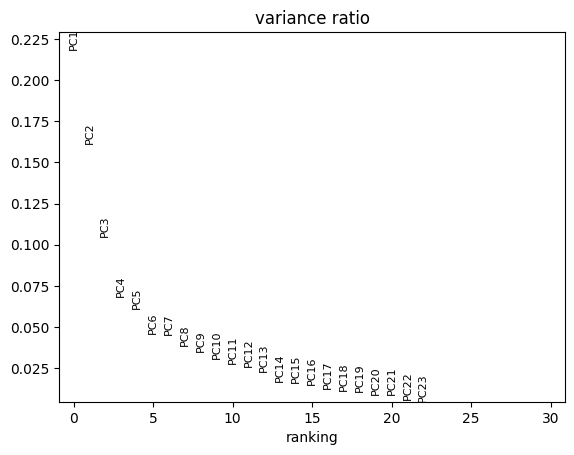

In [49]:
sc.tl.pca(sample, svd_solver="arpack")
sc.pl.pca_variance_ratio(sample, log=False)

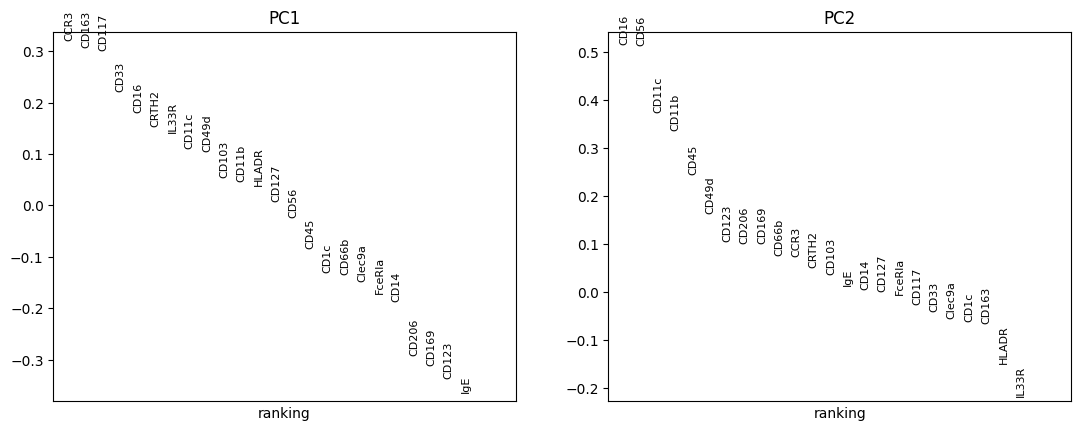

In [50]:
sc.pl.pca_loadings(sample, components = '1,2')

In [51]:
from preprocessing import pca_df
grouped_pca = pca_df(sample, session)

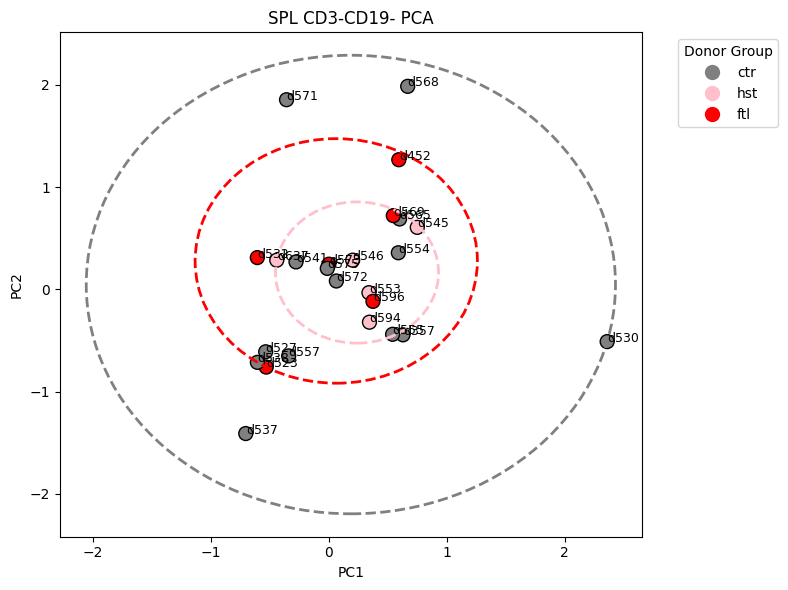

In [ ]:
from plotting_methods import pca_plot
pca_plot(grouped_pca, tissue_type, sample_name)

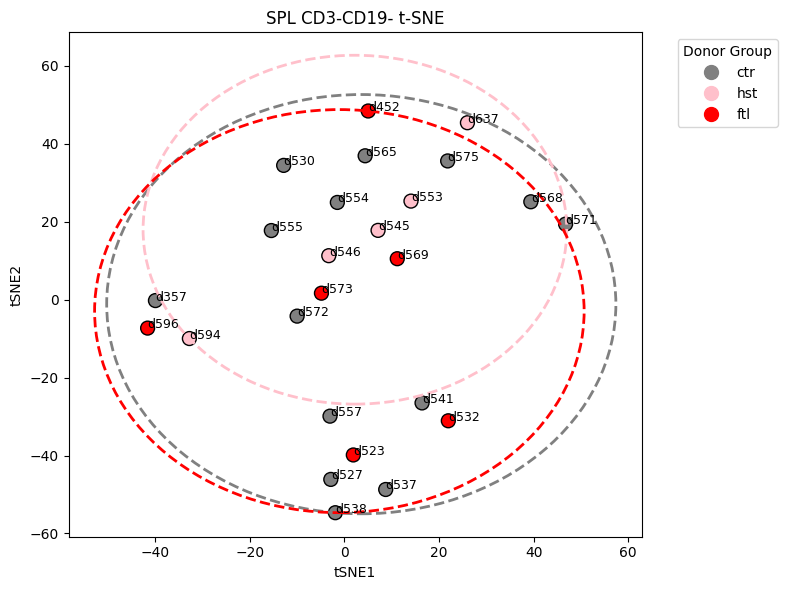

In [ ]:
from sklearn.manifold import TSNE
from plotting_methods import tSNE_plot
tSNE_plot(grouped_pca, tissue_type, sample_name)

computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:09)
running Leiden clustering
    finished: found 18 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:01:21)
running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:02)
--> added 'pos', the PAGA positions (adata.uns['paga'])


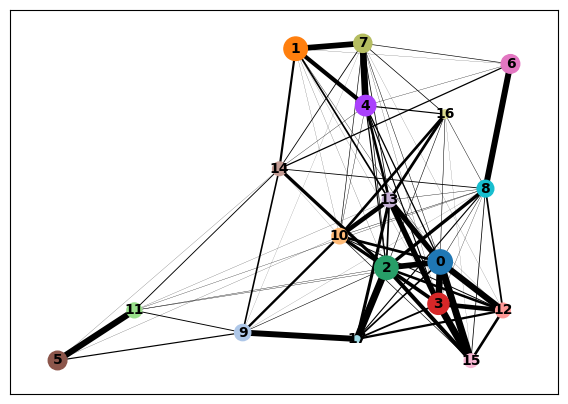

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:35)


In [54]:
sc.pp.neighbors(sample, n_neighbors=15, n_pcs= 15, random_state=0)
sc.tl.leiden(sample, resolution=0.8, flavor='leidenalg')
sc.tl.paga(sample)
sc.pl.paga(sample)
sc.tl.umap(sample, init_pos='paga', random_state=0)

In [55]:
markers = list(sample.var_names)

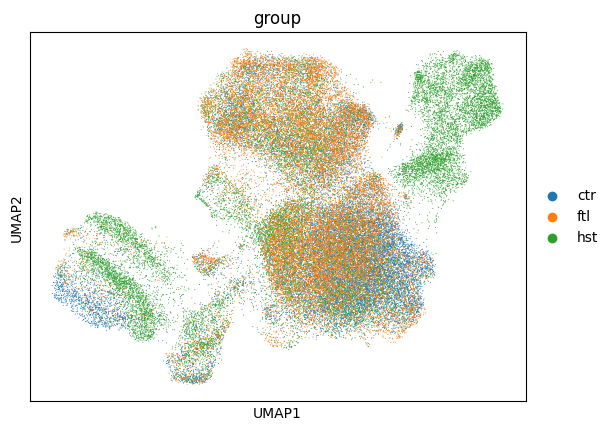

In [56]:
sc.pl.umap(sample, color= ['group'], cmap='turbo')

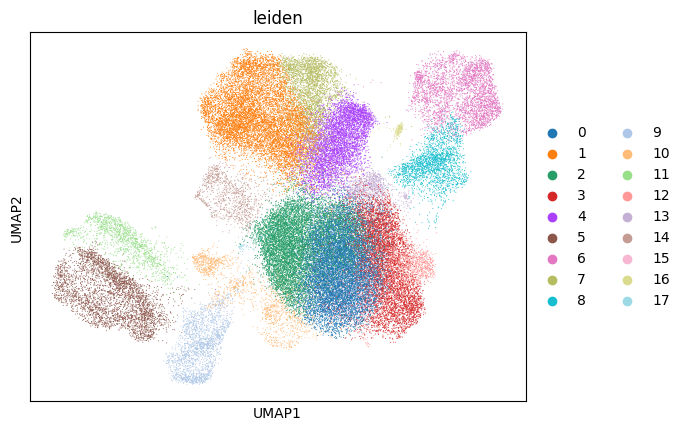

In [57]:
sc.pl.umap(sample, color= ['leiden'], cmap='turbo')

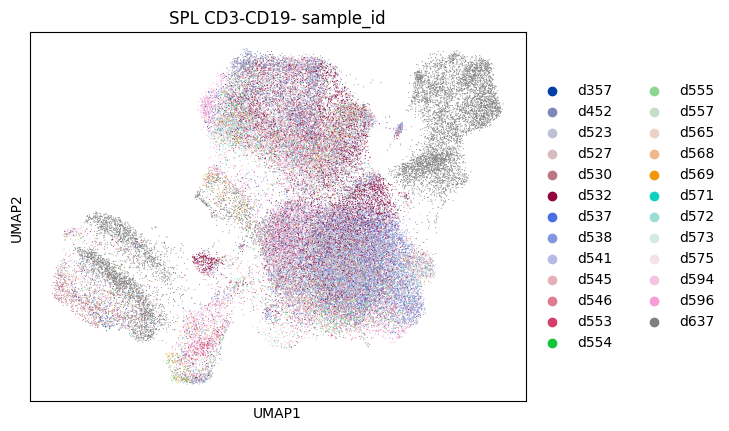

In [58]:
sc.pl.umap(sample, color= ['sample_id'], cmap='turbo', title = '{} {} sample_id'.format(tissue_type, sample_name))

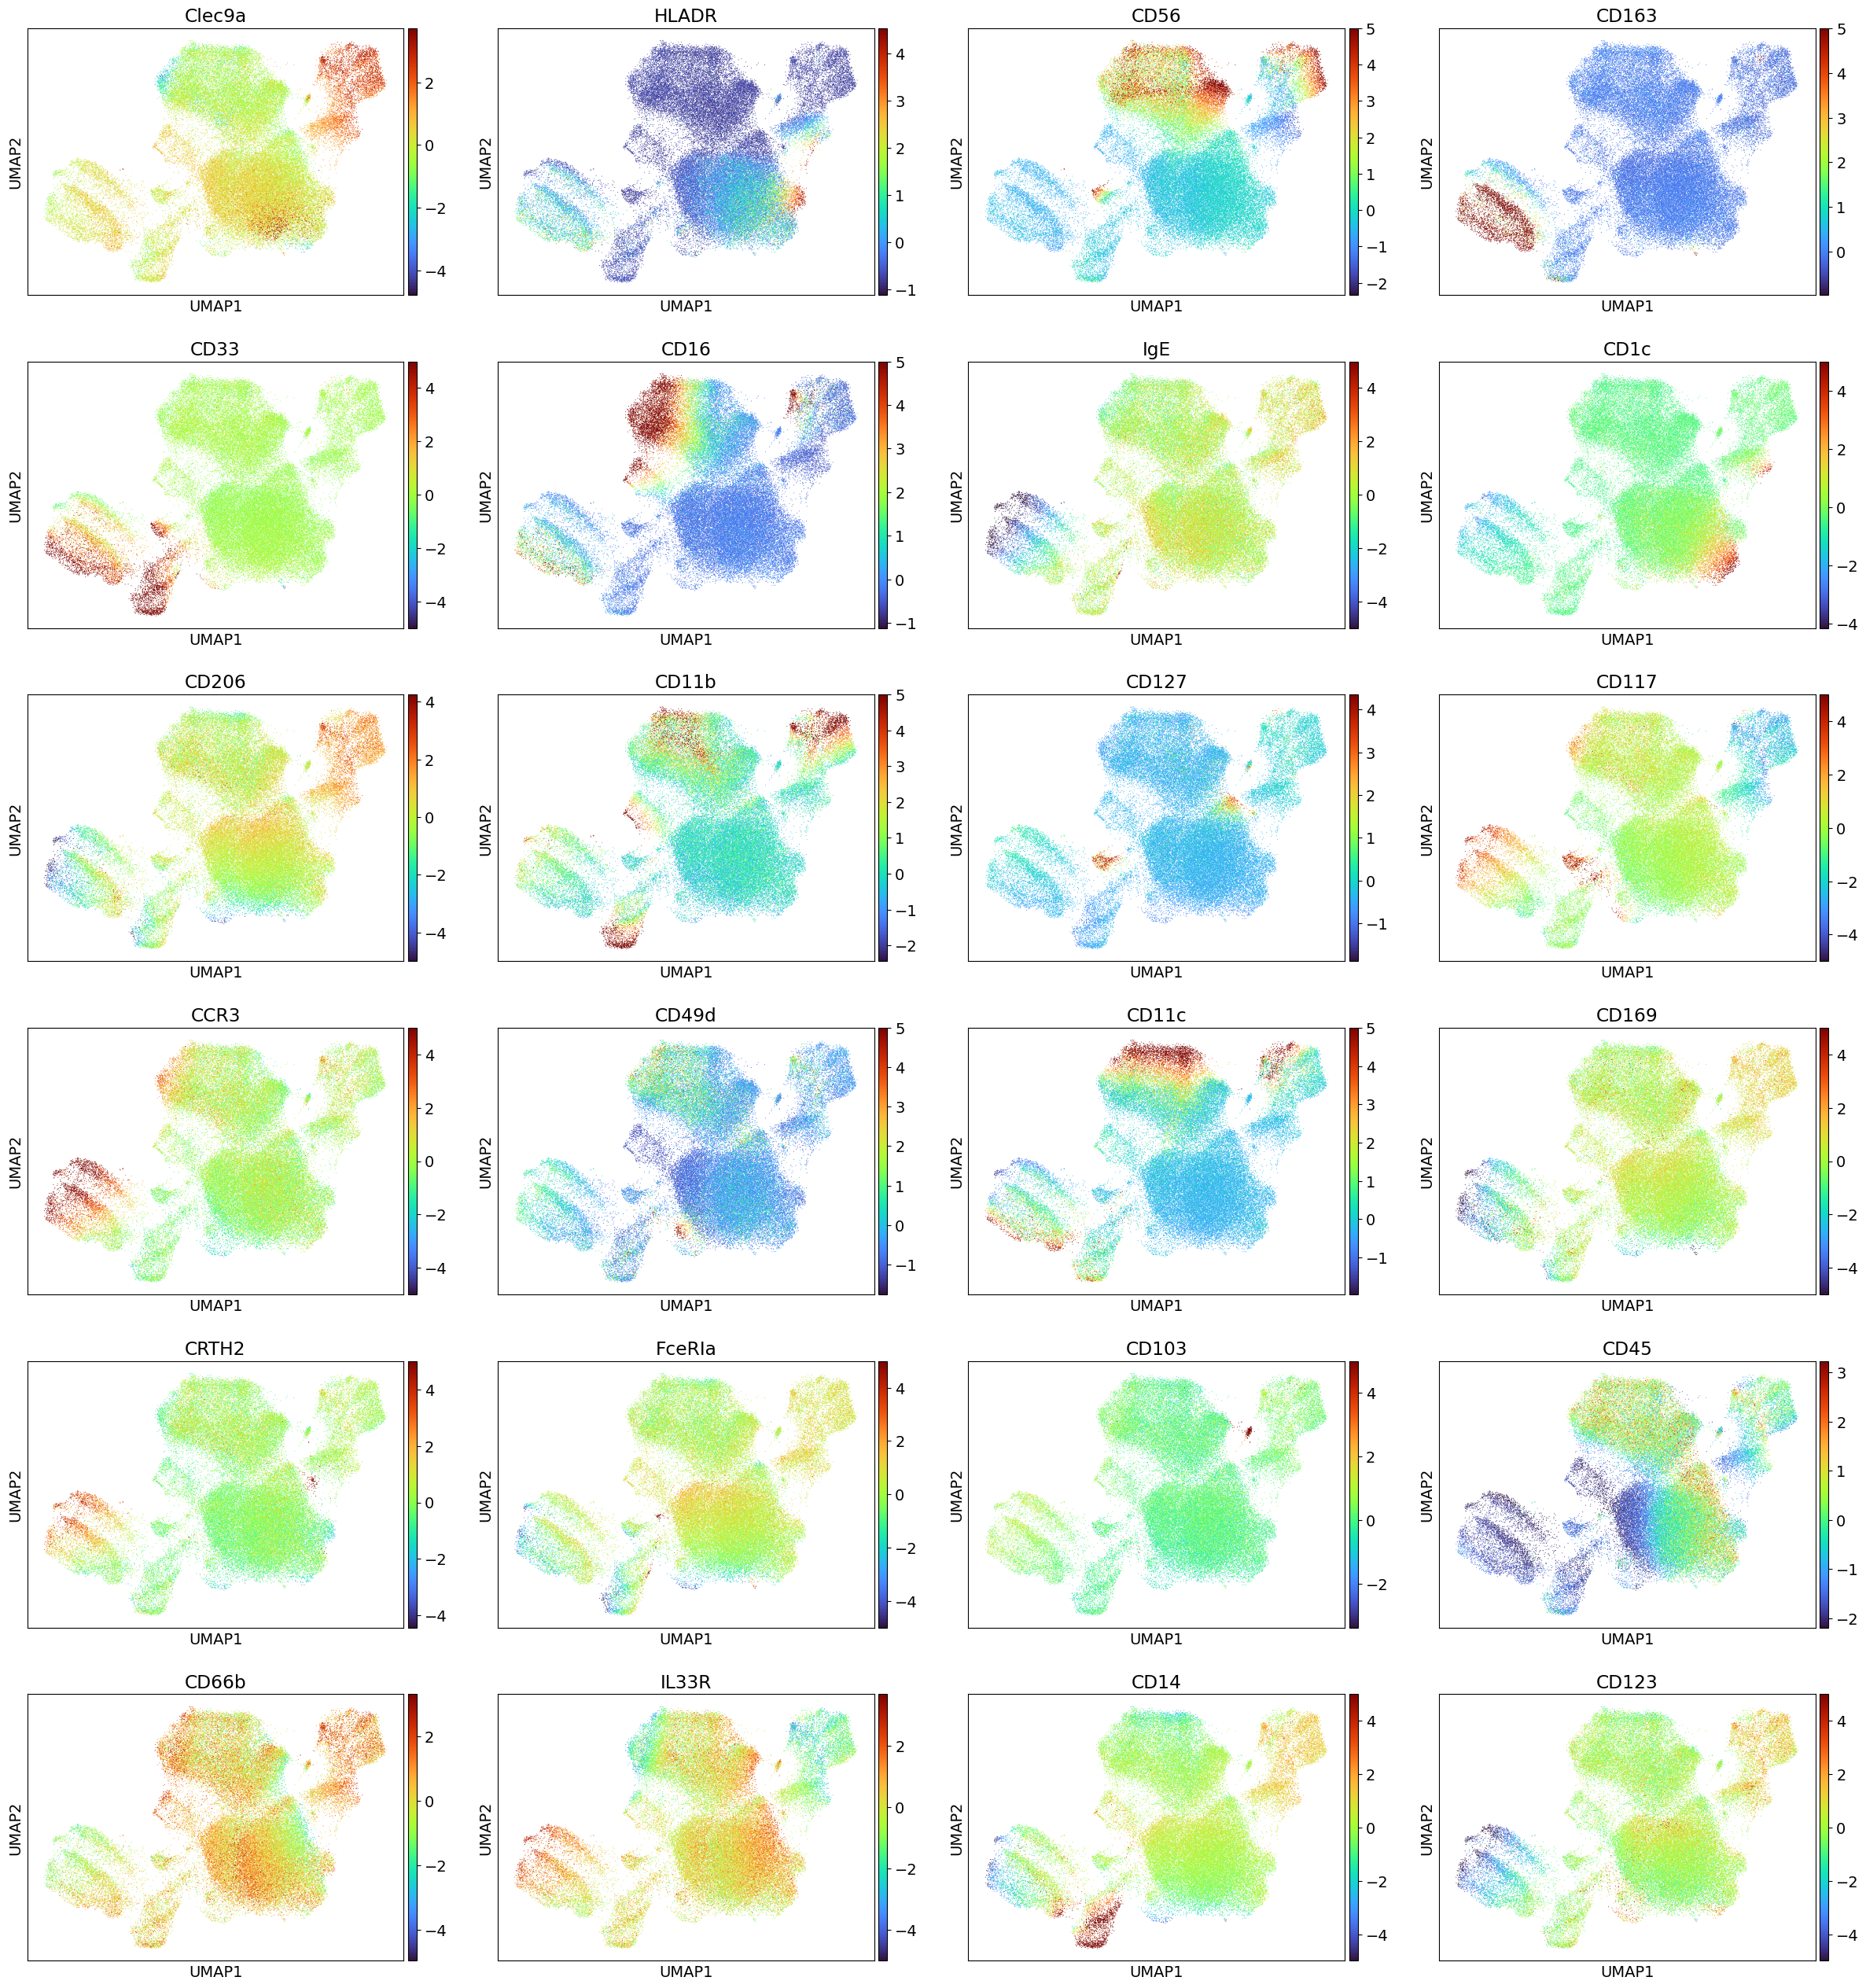

In [59]:
plt.rcParams.update({'font.size': 14})  
sc.pl.umap(sample, color=markers, cmap='turbo')


ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


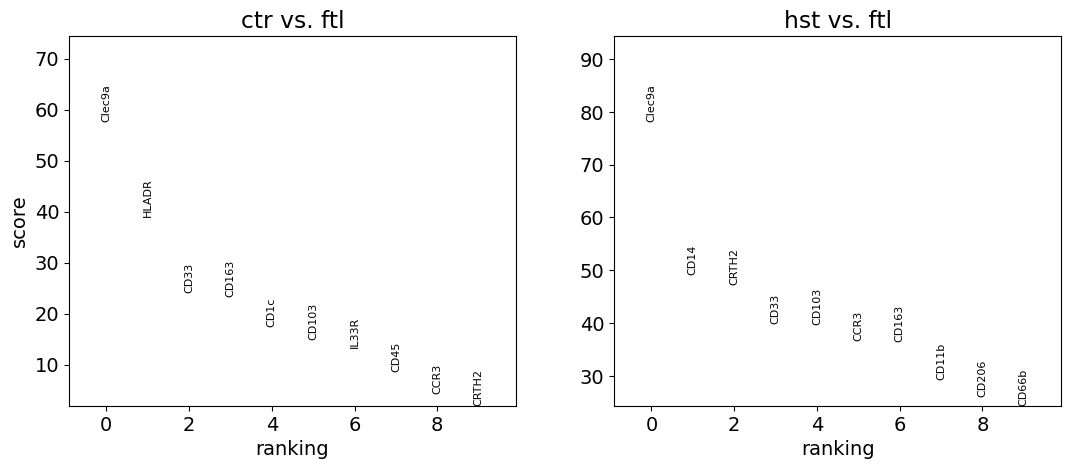

In [60]:
sc.tl.rank_genes_groups(sample, groupby='group', groups = ['ctr','hst'], reference = 'ftl', method='t-test')
sc.pl.rank_genes_groups(sample, n_genes=10, sharey=False)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


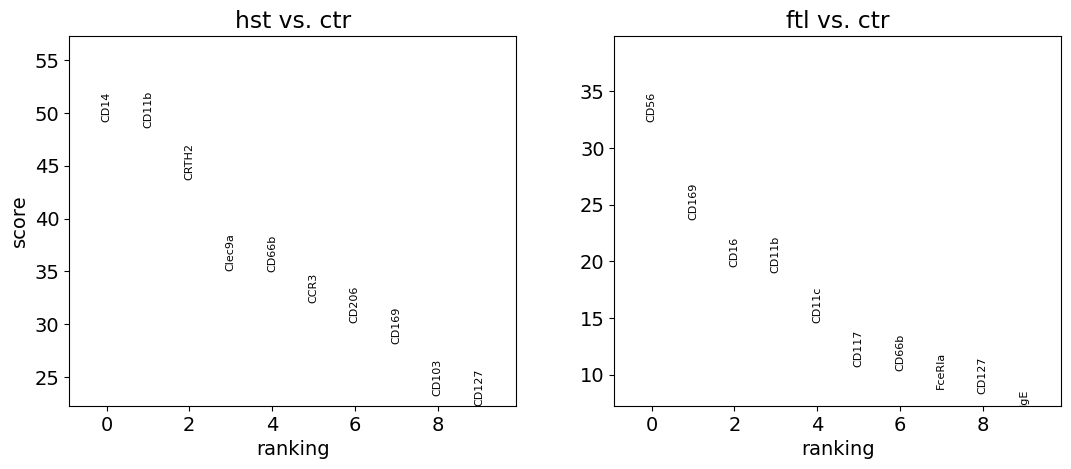

In [61]:
sc.tl.rank_genes_groups(sample, groupby='group', groups = ['hst', 'ftl'], reference = 'ctr', method='t-test')
sc.pl.rank_genes_groups(sample, n_genes=10, sharey=False)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


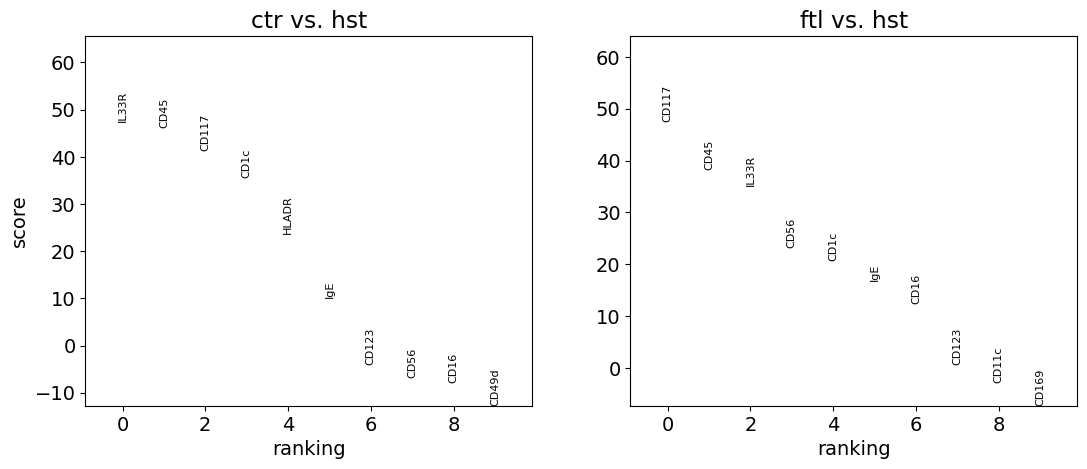

In [62]:
sc.tl.rank_genes_groups(sample, groupby='group', groups = ['ctr', 'ftl'], reference = 'hst', method='t-test')
sc.pl.rank_genes_groups(sample, n_genes=10, sharey=False)

In [63]:
sc.tl.rank_genes_groups(sample, "leiden", method="wilcoxon")
df = pd.DataFrame(
    {group: sample.uns["rank_genes_groups"]["names"][group] for group in sample.uns["rank_genes_groups"]["names"].dtype.names}
)
df.head(3)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: 

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,HLADR,CD16,FceRIa,CD1c,CD56,CD163,Clec9a,CD11c,Clec9a,CD33,CD33,CCR3,HLADR,CD127,CD16,Clec9a,CD103,FceRIa
1,CD1c,CD56,IgE,CD45,CD45,CD33,CD206,CD56,CD206,CD14,CD117,CRTH2,CD1c,CD45,CD11b,HLADR,CD127,HLADR
2,CD66b,CD49d,CD169,HLADR,IL33R,HLADR,CD11b,CD45,CD14,CD11b,CD123,CD117,IL33R,CD117,FceRIa,CD1c,IL33R,CD1c


In [64]:
result = sample.uns["rank_genes_groups"]
groups = result["names"].dtype.names

celltype = {'celltype': []}
cluster_to_genes = {}
for group in groups:
    top_genes = result["names"][group][:3]
    cluster_to_genes[group] = f"{':'.join(top_genes)} ({group})"

celltype['celltype'] = [cluster_to_genes[leiden] for leiden in sample.obs['leiden']]
sample.obs["celltype"] = celltype['celltype']

print(sample.obs[["leiden", "celltype"]].head())

       leiden                celltype
289212      3     CD1c:CD45:HLADR (3)
136874      7     CD11c:CD56:CD45 (7)
229327     15  Clec9a:HLADR:CD1c (15)
45563       7     CD11c:CD56:CD45 (7)
300700      4     CD56:CD45:IL33R (4)


In [65]:
plt.rcParams.update({'font.size': 10})  

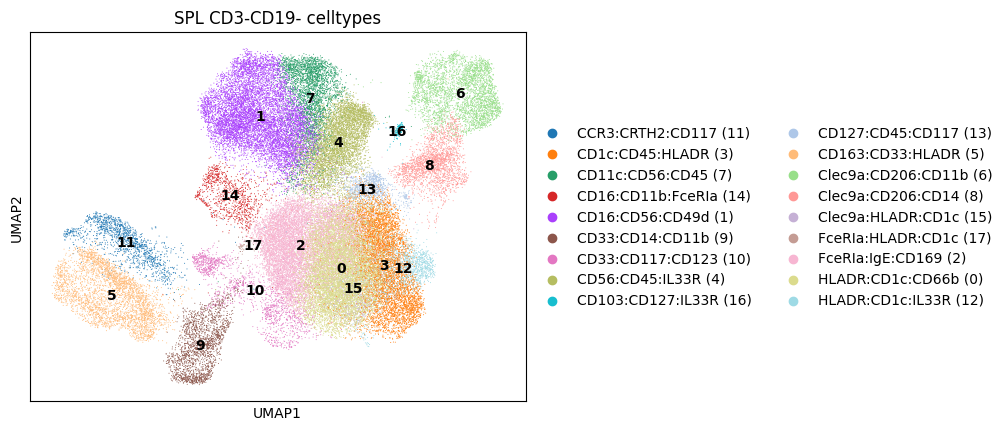

In [66]:
import scanpy as sc
import matplotlib.pyplot as plt

# Plot the UMAP
sc.pl.umap(
    sample,
    color=['celltype'],
    cmap='turbo',
    title = '{} {} celltypes'.format(tissue_type, sample_name),# Show legends directly on the UMAP
    show=False,            # Prevent immediate display
)

# Add cluster labels
ax = plt.gca()  # Get current axis
for cluster in sample.obs['leiden'].cat.categories:
    # Find the coordinates of cells in this cluster
    cluster_mask = sample.obs['leiden'] == cluster
    cluster_coords = sample.obsm['X_umap'][cluster_mask]
    # Calculate cluster centroid
    x, y = cluster_coords[:, 0].mean(), cluster_coords[:, 1].mean()
    # Add text label
    ax.text(x, y, cluster, color='black', fontsize=10, weight='bold', ha='center', va='center')

# Display the plot
plt.show()

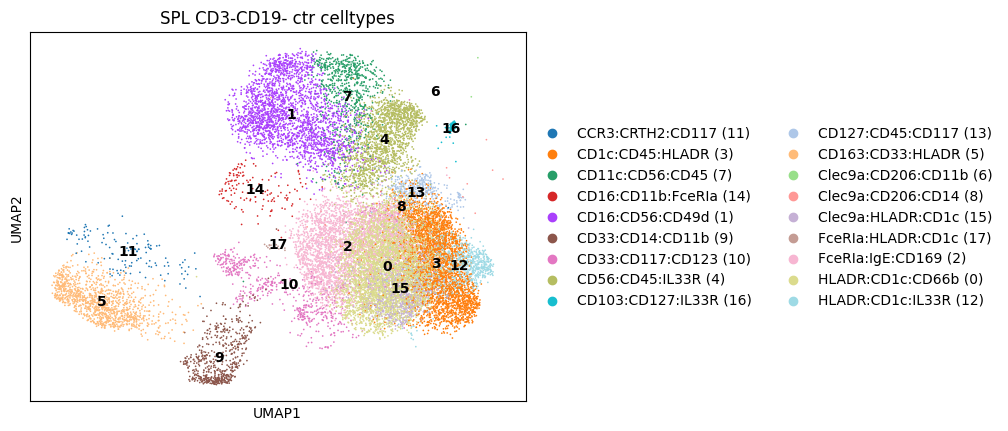

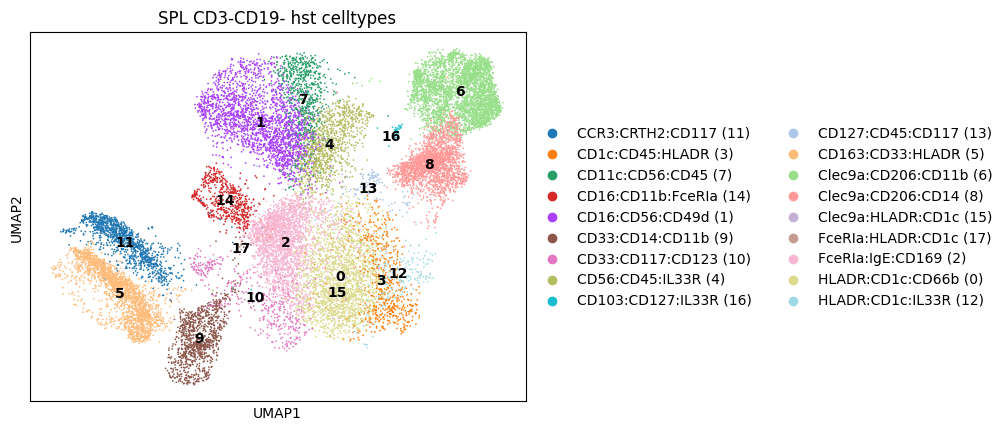

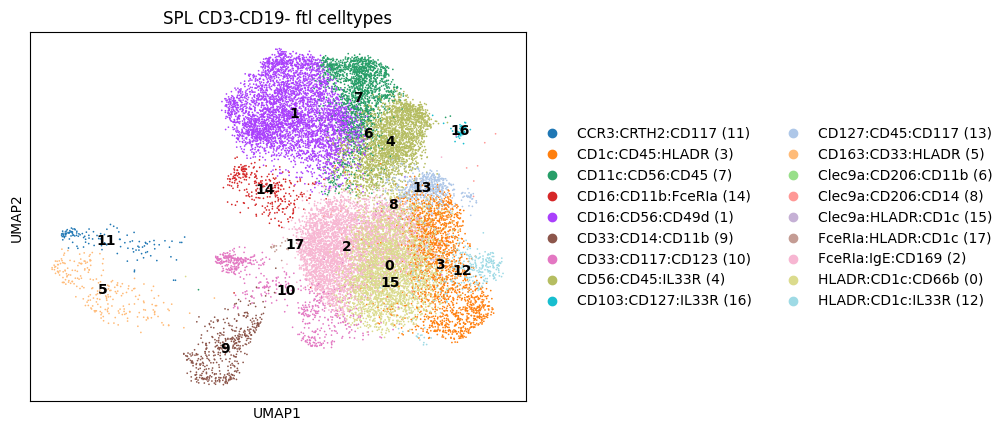

In [67]:
for group in ['ctr', 'hst', 'ftl']:
    adata_group = sample[sample.obs['group'] == group]
    
    sc.pl.umap(
    adata_group,
    color=['celltype'],
    title=f'{tissue_type} {sample_name} {group} celltypes',
    cmap='turbo', 
    show=False             
)

    ax = plt.gca()  
    for cluster in adata_group.obs['leiden'].cat.categories:
        cluster_mask = adata_group.obs['leiden'] == cluster
        cluster_coords = adata_group.obsm['X_umap'][cluster_mask]
        x, y = cluster_coords[:, 0].mean(), cluster_coords[:, 1].mean()
        ax.text(x, y, cluster, color='black', fontsize=10, weight='bold', ha='center', va='center')

    plt.show()

In [68]:
plt.rcParams.update({'font.size': 12})  

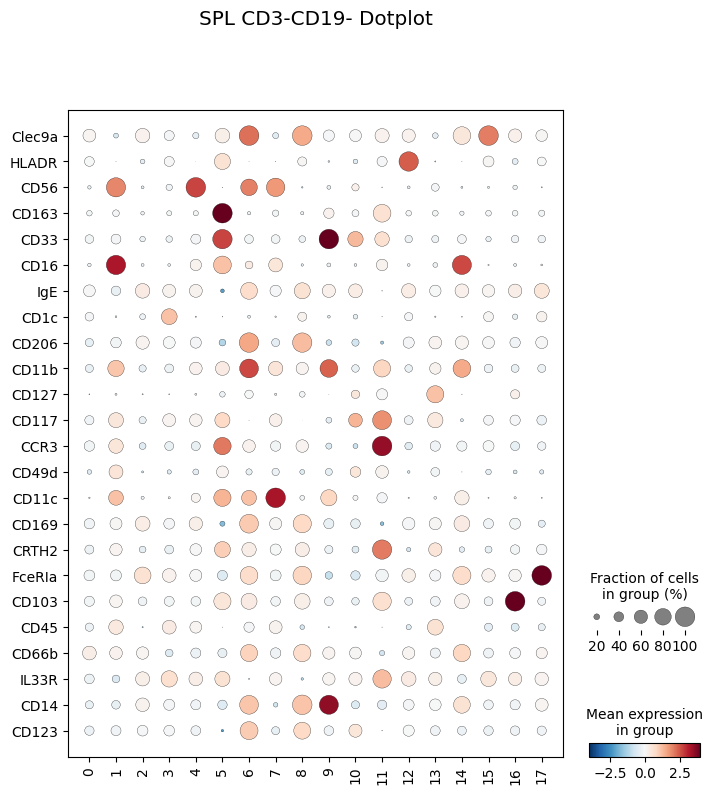

In [69]:
sc.pl.dotplot(sample, markers, swap_axes=True, groupby='leiden', title = "{} {} Dotplot".format(tissue_type, sample_name), cmap='RdBu_r', vmin = -4, vmax = 4)

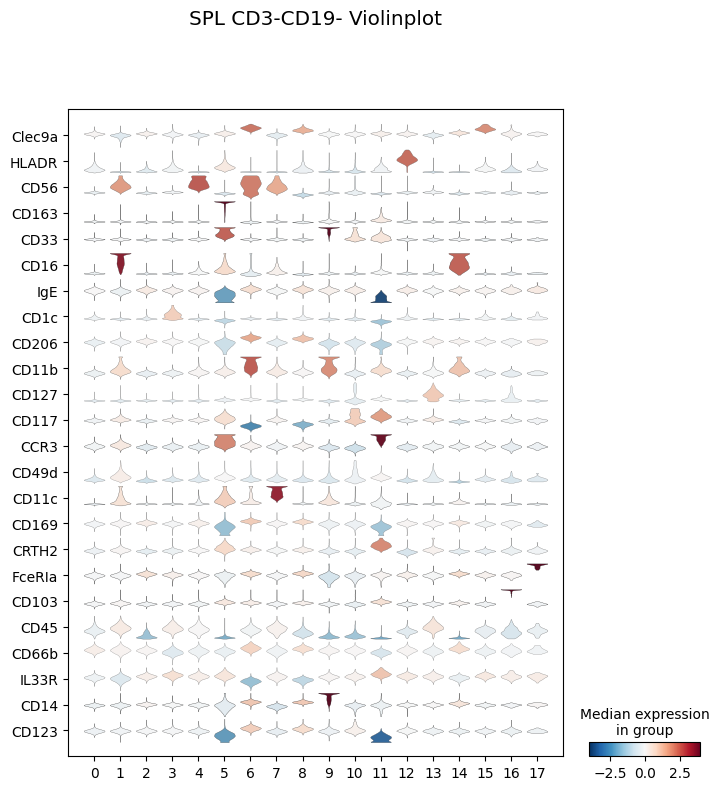

In [70]:
sc.pl.stacked_violin(sample, markers, swap_axes=True, groupby='leiden', title = "{} {} Violinplot".format(tissue_type, sample_name), cmap='RdBu_r', vmin = -4, vmax = 4)